In [ ]:
!pip install -q segmentation-models-pytorch opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import VOCSegmentation
from torchvision import transforms
import segmentation_models_pytorch as smp
from tqdm import tqdm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_CLASSES = 21

In [ ]:
img_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

In [ ]:
class VOCDataset(torch.utils.data.Dataset):
    def __init__(self, split):
        self.dataset = VOCSegmentation(
            root="data",
            year="2012",
            image_set=split,
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        img = img_transform(img)
        mask = mask_transform(mask).long().squeeze()

        # Remove the problematic line that replaces ignore label 255 -> 0
        # mask[mask == 255] = 0

        return img, mask

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)

In [ ]:
train_ds = VOCDataset("train")
val_ds = VOCDataset("val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

100%|██████████| 2.00G/2.00G [03:00<00:00, 11.1MB/s]


In [ ]:
def mean_iou(pred, target, num_classes=NUM_CLASSES):
    pred = pred.view(-1)
    target = target.view(-1)
    ious = []

    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union > 0:
            ious.append(intersection / union)

    return sum(ious) / len(ious)

In [ ]:
def train_model(model, optimizer, loss_fn, epochs=5):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, masks in tqdm(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

In [ ]:
def evaluate_model(model):
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            total_iou += mean_iou(preds, masks)

    return total_iou / len(val_loader)

In [ ]:
unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

# Pass ignore_index=255 to DiceLoss to correctly ignore the 255 label
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)

print("Training U-Net...")
train_model(unet, optimizer, loss_fn, epochs=5)

unet_iou = evaluate_model(unet)
print("U-Net mIoU:", unet_iou)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Training U-Net...


100%|██████████| 366/366 [00:34<00:00, 10.66it/s]


...

Epoch [3/5] Loss: 0.8724


100%|██████████| 366/366 [00:33<00:00, 10.79it/s]


Epoch [4/5] Loss: 0.7974


100%|██████████| 366/366 [00:33<00:00, 10.90it/s]


Epoch [5/5] Loss: 0.7184
U-Net mIoU: 0.14897155125507414


In [ ]:
deeplab = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

optimizer = torch.optim.Adam(deeplab.parameters(), lr=1e-4)

print("Training DeepLabV3+...")
train_model(deeplab, optimizer, loss_fn, epochs=5)

deeplab_iou = evaluate_model(deeplab)
print("DeepLabV3+ mIoU:", deeplab_iou)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Training DeepLabV3+...


100%|██████████| 366/366 [00:46<00:00,  7.93it/s]


Epoch [1/5] Loss: 1.3886


...

Epoch [3/5] Loss: 0.5261


100%|██████████| 366/366 [00:45<00:00,  8.01it/s]


Epoch [4/5] Loss: 0.4207


100%|██████████| 366/366 [00:45<00:00,  7.97it/s]


Epoch [5/5] Loss: 0.3404
DeepLabV3+ mIoU: 0.34864010862648775


In [14]:
segformer = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
    activation=None
).to(device)

optimizer = torch.optim.Adam(segformer.parameters(), lr=1e-4)

print("Training SegFormer...")
train_model(segformer, optimizer, loss_fn, epochs=5)

segformer_iou = evaluate_model(segformer)
print("SegFormer mIoU:", segformer_iou)

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

Training SegFormer...


100%|██████████| 366/366 [00:52<00:00,  6.93it/s]


Epoch [1/5] Loss: 0.9600


...

Epoch [3/5] Loss: 0.2179


100%|██████████| 366/366 [00:48<00:00,  7.57it/s]


Epoch [4/5] Loss: 0.1541


100%|██████████| 366/366 [00:48<00:00,  7.51it/s]


Epoch [5/5] Loss: 0.1578
SegFormer mIoU: 0.4710377898068272


In [15]:
def visualize(model):
    model.eval()
    img, mask = val_ds[0]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(pred, dim=1).squeeze().cpu()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img.permute(1,2,0))

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask)

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred)
    plt.show()

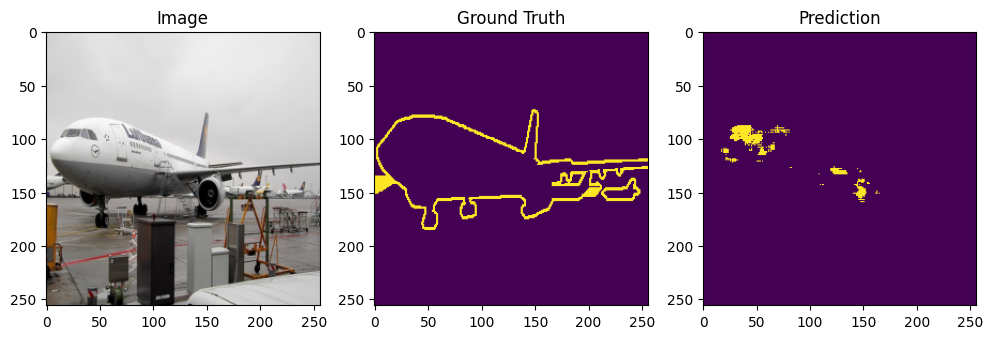

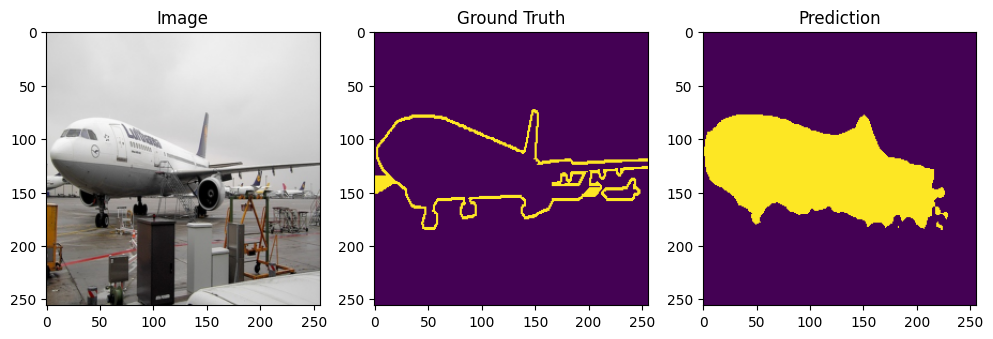

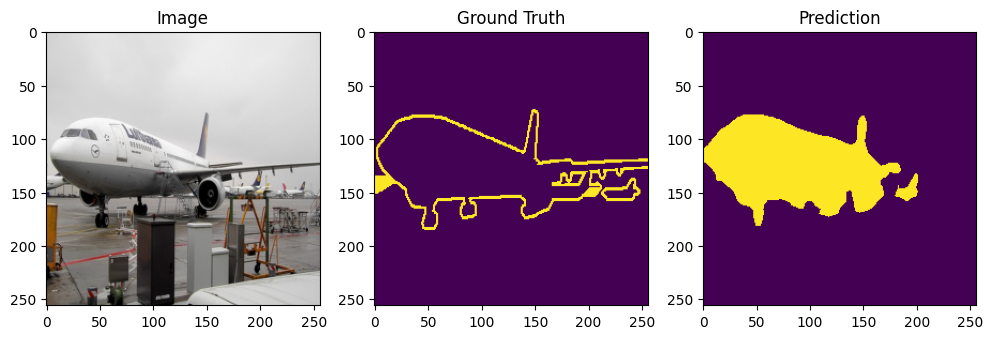

In [16]:
visualize(unet)
visualize(deeplab)
visualize(segformer)